# Exercise 2: Autoencoders on Fashion-MNIST

This notebook is the submission template for Exercise 2. Fill in the cells marked `TODO` / `YOUR CODE HERE` and keep the provided function names, class names, and cell order unchanged so the notebook can be graded automatically.

You will implement:

1. a fully connected autoencoder,
2. a denoising autoencoder using the same fully connected model,
3. a convolutional autoencoder,
4. short written comparisons of the reconstruction quality.

## Submission Notes

Run the notebook from top to bottom before submitting. Export a PDF version as requested in the assignment, and submit both the `.ipynb` and PDF in your ZIP file.

The training cells save the best model weights as `.pth` files. You may lower `args.epochs` while debugging, but for the final run it should be at least `50` epochs as specified in the exercise sheet.

In [1]:
import os
from types import SimpleNamespace

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (12.0, 6.0)
plt.rcParams['image.cmap'] = 'gray'

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## Config

These hyperparameters follow the assignment specification. Keep them unchanged for the final submission unless your tutor explicitly says otherwise.

In [3]:
args = SimpleNamespace()
args.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args.cuda = args.device.type == 'cuda'
args.test_batch_size = 10
args.batch_size = 128
args.lr = 0.001
args.weight_decay = 1e-5
args.log_interval = 100
args.epochs = 50
args.noise_factor = 0.5
args.is_noisy = False

print(f'Using device: {args.device}')

Using device: cuda


## Helper Functions

These cells are provided. You do not need to edit them.

In [4]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor


def to_img(x, shape=(28, 28)):
    """Map a flattened tensor from [-1, 1] to image tensors in [0, 1]."""
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, shape[0], shape[1])
    return x


def add_white_noise(x, factor=0.5, stddev=1):
    noise = x.clone().normal_(0, stddev)
    return x + noise * factor


class AddWhiteNoise(object):
    def __init__(self, stddev=1, noise_factor=0.5):
        self.stddev = stddev
        self.factor = noise_factor

    def __call__(self, tensor):
        tensor = add_white_noise(tensor, factor=self.factor, stddev=self.stddev)
        return tensor.clamp_(0, 1)

## Data Preparation

Fashion-MNIST images are normalized to the range `[-1, 1]`, which is why the models use `Tanh` in their final decoder layer.

In [5]:
train_mean, train_std = (0.5,), (0.5,)

train_loader = DataLoader(
    datasets.FashionMNIST(
        './data_fmnist',
        train=True,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(train_mean, train_std),
        ]),
    ),
    batch_size=args.batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    datasets.FashionMNIST(
        './data_fmnist',
        train=False,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(train_mean, train_std),
        ]),
    ),
    batch_size=args.test_batch_size,
    shuffle=False,
)

100.0%
100.0%
100.0%
100.0%


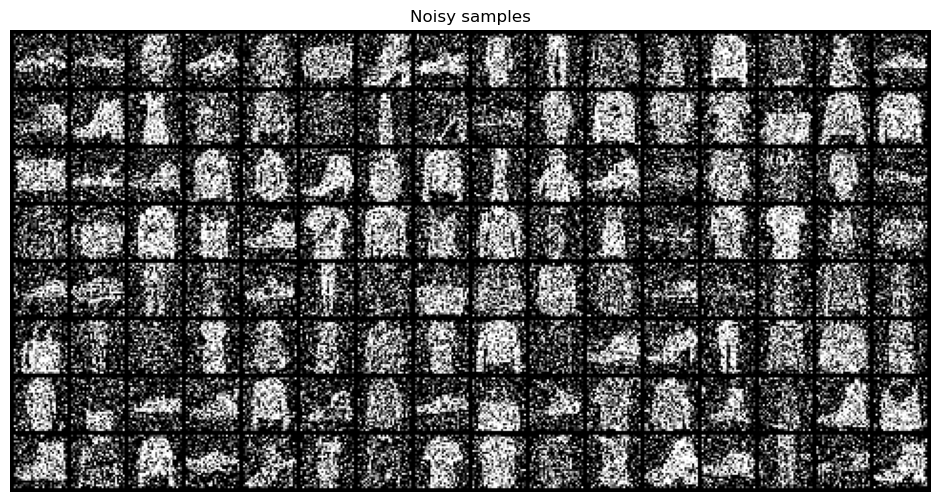

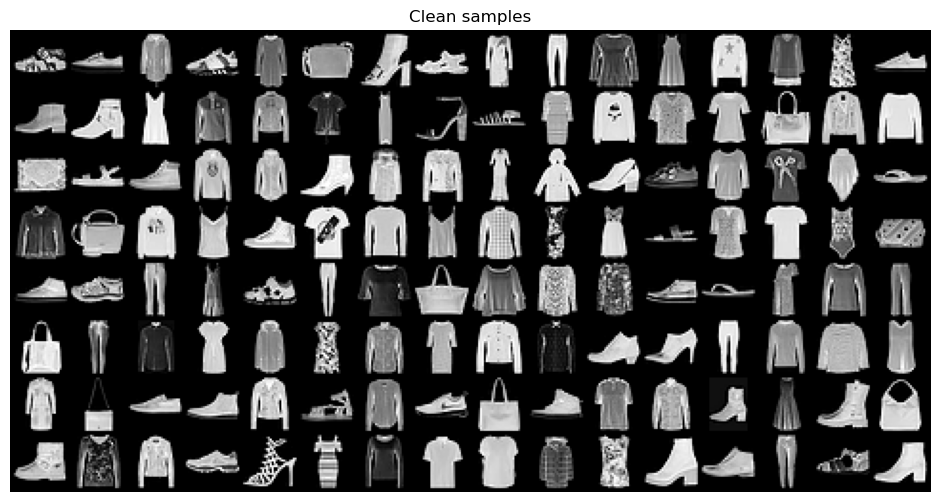

In [6]:
# Display a clean and noisy batch.
in_img = next(iter(train_loader))[0]
inputs = torch.stack([UnNormalize(train_mean, train_std)(in_img[i].clone()) for i in range(in_img.shape[0])])
noisy_inputs = AddWhiteNoise(noise_factor=args.noise_factor)(inputs.clone())

plt.imshow(transforms.ToPILImage()(make_grid(noisy_inputs, nrow=16)))
plt.title('Noisy samples')
plt.axis('off')
plt.show()

plt.imshow(transforms.ToPILImage()(make_grid(inputs, nrow=16)))
plt.title('Clean samples')
plt.axis('off')
plt.show()

# Task 1: Fully Connected Autoencoder

Implement the `Autoencoder` class below.

Encoder architecture:

- `Linear(784, 128)` + `ReLU`
- `Linear(128, 64)` + `ReLU`
- `Linear(64, 32)` + `ReLU`
- `Linear(32, 16)` + `ReLU`
- `Linear(16, 8)` + `ReLU`

Decoder architecture:

- `Linear(8, 8)` + `ReLU`
- `Linear(8, 32)` + `ReLU`
- `Linear(32, 64)` + `ReLU`
- `Linear(64, 128)` + `ReLU`
- `Linear(128, 784)` + `Tanh`

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, input_shape=(28, 28)):
        super(Autoencoder, self).__init__()
        input_dim = int(np.prod(input_shape))

        encoder_layers = [
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        ]
        if not encoder_layers:
            raise NotImplementedError('TODO 1.1: implement the fully connected encoder.')
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = [
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Tanh()
        ]
        if not decoder_layers:
            raise NotImplementedError('TODO 1.2: implement the fully connected decoder.')
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction

In [9]:
# Run this after completing Task 1. The output shape must match the flattened input shape.
fc_shape_test = Autoencoder()
with torch.no_grad():
    dummy = torch.randn(4, 28 * 28)
    assert fc_shape_test(dummy).shape == dummy.shape
print('Autoencoder shape check passed.')

Autoencoder shape check passed.


## Training and Evaluation Code

These functions are shared by all three tasks. You do not need to edit them.

In [10]:
def initialize_training(model):
    model = model.to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    criterion = nn.MSELoss()
    return model, optimizer, criterion


def prepare_batch(data, noisy=False):
    data = data.view(data.size(0), -1).to(args.device)
    if noisy:
        data_in = add_white_noise(data.clone(), factor=args.noise_factor)
        data_in.clamp_(-train_mean[0] / train_std[0], (1 - train_mean[0]) / train_std[0])
    else:
        data_in = data
    return data_in, data


def train_one_epoch(model, optimizer, criterion, epoch, noisy=False):
    model.train()
    running_loss = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data_in, target = prepare_batch(data, noisy=noisy)
        output = model(data_in)
        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % args.log_interval == 0:
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100.0 * batch_idx / len(train_loader),
                    loss.item(),
                )
            )

    avg_loss = running_loss / len(train_loader)
    print('Train Epoch: {} Average loss: {:.6f}'.format(epoch, avg_loss))
    return avg_loss


def plot_reconstruction(data_in, output, target, noisy=False):
    if noisy:
        plt.imshow(transforms.ToPILImage()(make_grid(to_img(data_in.cpu()))))
        plt.title('Noisy input')
        plt.axis('off')
        plt.show()

    plt.imshow(transforms.ToPILImage()(make_grid(to_img(output.cpu()))))
    plt.title('Reconstruction')
    plt.axis('off')
    plt.show()

    plt.imshow(transforms.ToPILImage()(make_grid(to_img(target.cpu()))))
    plt.title('Target')
    plt.axis('off')
    plt.show()


def test(model, show_plot=False, noisy=False):
    model.eval()
    test_loss = 0.0
    criterion_sum = nn.MSELoss(reduction='sum')

    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            data_in, target = prepare_batch(data, noisy=noisy)
            output = model(data_in)
            test_loss += criterion_sum(output, target).item()

            if show_plot and i == 0:
                plot_reconstruction(data_in, output, target, noisy=noisy)

    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}\n'.format(test_loss))
    return test_loss


def run_experiment(model, save_path, noisy=False):
    model, optimizer, criterion = initialize_training(model)
    best_loss = float('inf')

    test(model, show_plot=True, noisy=noisy)
    for epoch in range(1, args.epochs + 1):
        train_one_epoch(model, optimizer, criterion, epoch, noisy=noisy)
        test_loss = test(model, show_plot=(epoch % 10 == 0), noisy=noisy)

        if test_loss < best_loss:
            best_loss = test_loss
            torch.save(model.state_dict(), save_path)

    print('The best (lowest) achieved loss: {:.3f}\n'.format(best_loss))
    return best_loss

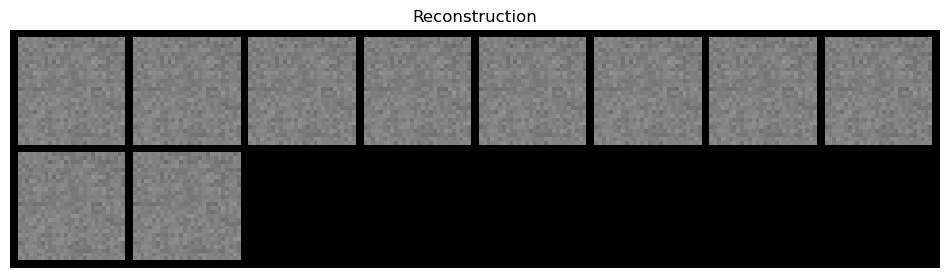

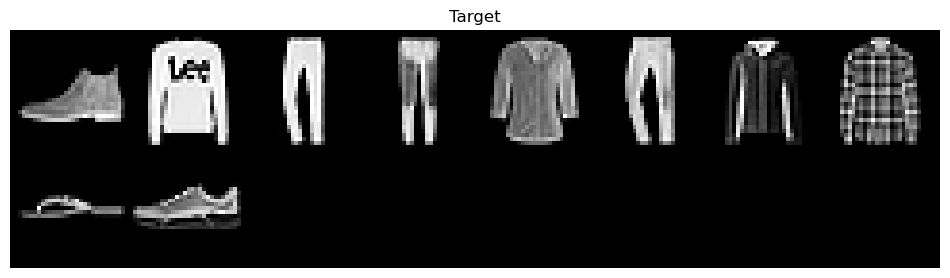


Test set: Average loss: 535.9782

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.686385
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.273120
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.167884
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.169244
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.158591
Train Epoch: 1 Average loss: 0.215010

Test set: Average loss: 114.1775

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.137671
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.152422
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.130134
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.114292
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.105804
Train Epoch: 2 Average loss: 0.128553

Test set: Average loss: 90.8615

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.121524
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.118456
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.099250
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.111304
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.100251
Train Epoch: 3 Average loss: 0.106680

Test set: Average loss: 76.3064

Train Epoch: 

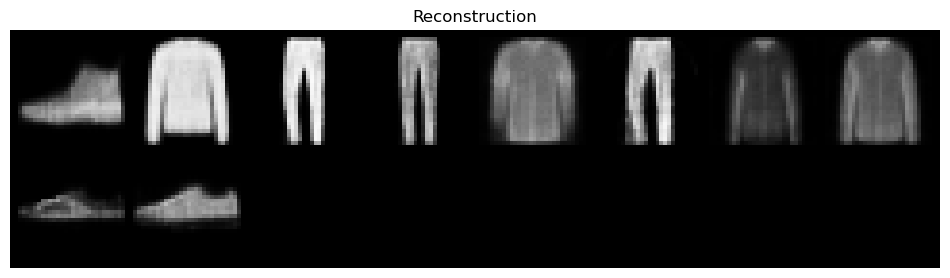

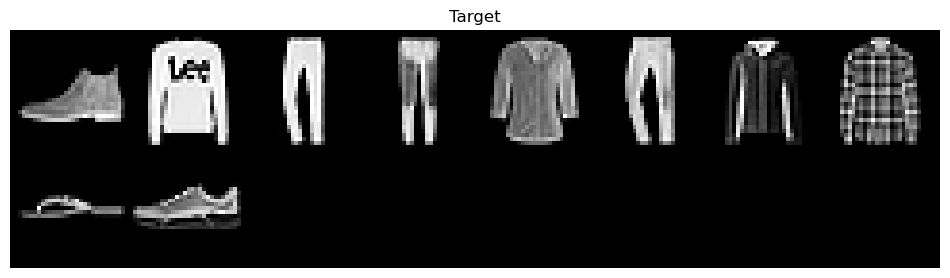


Test set: Average loss: 65.9858

Train Epoch: 11 [0/60000 (0%)]	Loss: 0.082488
Train Epoch: 11 [12800/60000 (21%)]	Loss: 0.085228
Train Epoch: 11 [25600/60000 (43%)]	Loss: 0.082092
Train Epoch: 11 [38400/60000 (64%)]	Loss: 0.079595
Train Epoch: 11 [51200/60000 (85%)]	Loss: 0.083854
Train Epoch: 11 Average loss: 0.083405

Test set: Average loss: 65.4256

Train Epoch: 12 [0/60000 (0%)]	Loss: 0.083901
Train Epoch: 12 [12800/60000 (21%)]	Loss: 0.085419
Train Epoch: 12 [25600/60000 (43%)]	Loss: 0.078721
Train Epoch: 12 [38400/60000 (64%)]	Loss: 0.076620
Train Epoch: 12 [51200/60000 (85%)]	Loss: 0.083110
Train Epoch: 12 Average loss: 0.082772

Test set: Average loss: 65.1708

Train Epoch: 13 [0/60000 (0%)]	Loss: 0.085366
Train Epoch: 13 [12800/60000 (21%)]	Loss: 0.075168
Train Epoch: 13 [25600/60000 (43%)]	Loss: 0.077800
Train Epoch: 13 [38400/60000 (64%)]	Loss: 0.086533
Train Epoch: 13 [51200/60000 (85%)]	Loss: 0.084516
Train Epoch: 13 Average loss: 0.082185

Test set: Average loss: 64.650

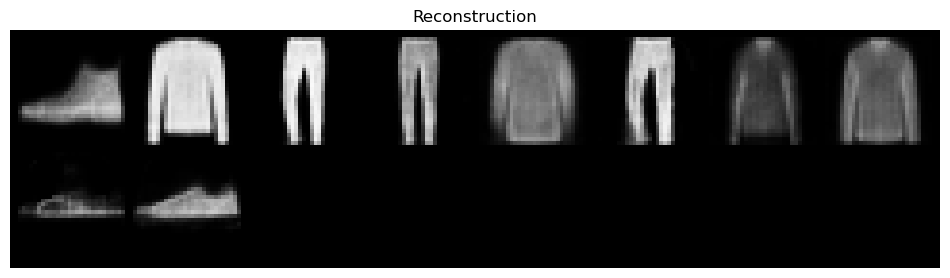

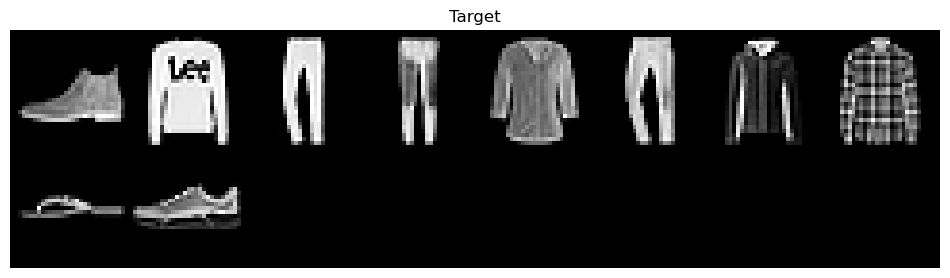


Test set: Average loss: 62.9091

Train Epoch: 21 [0/60000 (0%)]	Loss: 0.074797
Train Epoch: 21 [12800/60000 (21%)]	Loss: 0.075360
Train Epoch: 21 [25600/60000 (43%)]	Loss: 0.080101
Train Epoch: 21 [38400/60000 (64%)]	Loss: 0.074794
Train Epoch: 21 [51200/60000 (85%)]	Loss: 0.085834
Train Epoch: 21 Average loss: 0.079262

Test set: Average loss: 62.4690

Train Epoch: 22 [0/60000 (0%)]	Loss: 0.080885
Train Epoch: 22 [12800/60000 (21%)]	Loss: 0.082110
Train Epoch: 22 [25600/60000 (43%)]	Loss: 0.078992
Train Epoch: 22 [38400/60000 (64%)]	Loss: 0.080199
Train Epoch: 22 [51200/60000 (85%)]	Loss: 0.079424
Train Epoch: 22 Average loss: 0.079029

Test set: Average loss: 62.2984

Train Epoch: 23 [0/60000 (0%)]	Loss: 0.083372
Train Epoch: 23 [12800/60000 (21%)]	Loss: 0.074692
Train Epoch: 23 [25600/60000 (43%)]	Loss: 0.079500
Train Epoch: 23 [38400/60000 (64%)]	Loss: 0.076736
Train Epoch: 23 [51200/60000 (85%)]	Loss: 0.081062
Train Epoch: 23 Average loss: 0.078722

Test set: Average loss: 62.578

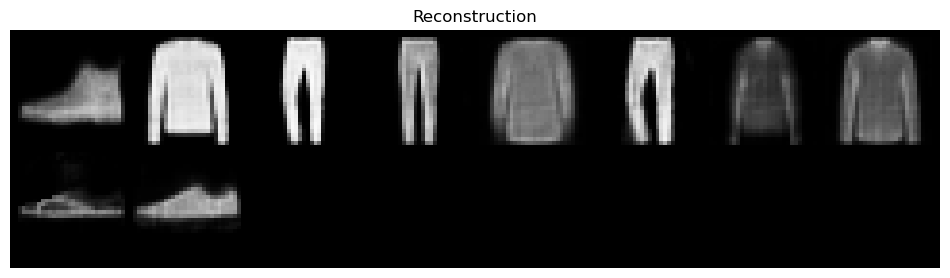

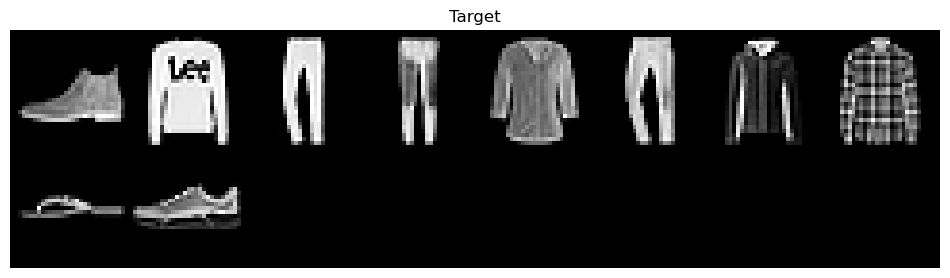


Test set: Average loss: 61.2044

Train Epoch: 31 [0/60000 (0%)]	Loss: 0.084164
Train Epoch: 31 [12800/60000 (21%)]	Loss: 0.081247
Train Epoch: 31 [25600/60000 (43%)]	Loss: 0.075194
Train Epoch: 31 [38400/60000 (64%)]	Loss: 0.072455
Train Epoch: 31 [51200/60000 (85%)]	Loss: 0.076890
Train Epoch: 31 Average loss: 0.077318

Test set: Average loss: 61.2403

Train Epoch: 32 [0/60000 (0%)]	Loss: 0.072726
Train Epoch: 32 [12800/60000 (21%)]	Loss: 0.070355
Train Epoch: 32 [25600/60000 (43%)]	Loss: 0.075949
Train Epoch: 32 [38400/60000 (64%)]	Loss: 0.073315
Train Epoch: 32 [51200/60000 (85%)]	Loss: 0.073312
Train Epoch: 32 Average loss: 0.077144

Test set: Average loss: 61.4094

Train Epoch: 33 [0/60000 (0%)]	Loss: 0.079001
Train Epoch: 33 [12800/60000 (21%)]	Loss: 0.079905
Train Epoch: 33 [25600/60000 (43%)]	Loss: 0.080007
Train Epoch: 33 [38400/60000 (64%)]	Loss: 0.081161
Train Epoch: 33 [51200/60000 (85%)]	Loss: 0.069343
Train Epoch: 33 Average loss: 0.077078

Test set: Average loss: 60.820

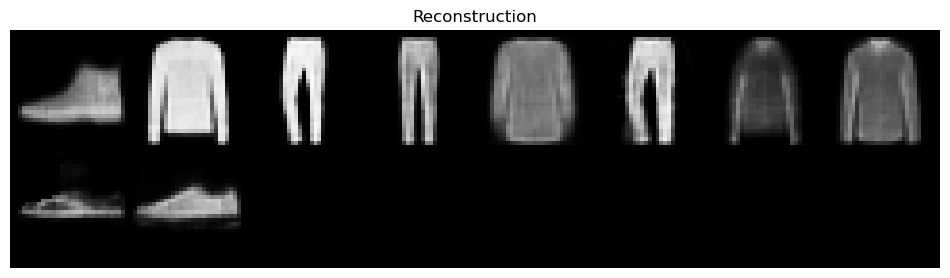

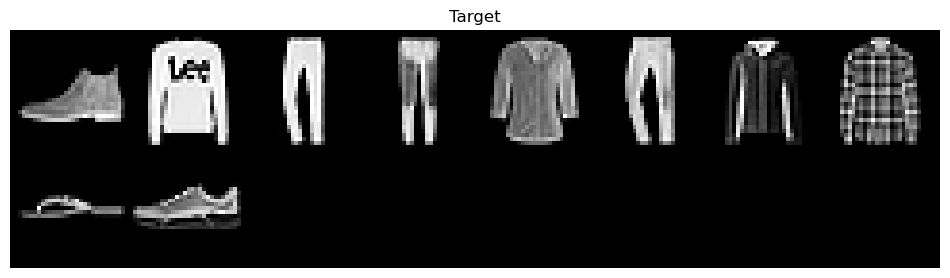


Test set: Average loss: 60.4193

Train Epoch: 41 [0/60000 (0%)]	Loss: 0.078517
Train Epoch: 41 [12800/60000 (21%)]	Loss: 0.073714
Train Epoch: 41 [25600/60000 (43%)]	Loss: 0.073572
Train Epoch: 41 [38400/60000 (64%)]	Loss: 0.079123
Train Epoch: 41 [51200/60000 (85%)]	Loss: 0.074492
Train Epoch: 41 Average loss: 0.076094

Test set: Average loss: 60.4443

Train Epoch: 42 [0/60000 (0%)]	Loss: 0.073679
Train Epoch: 42 [12800/60000 (21%)]	Loss: 0.072803
Train Epoch: 42 [25600/60000 (43%)]	Loss: 0.073667
Train Epoch: 42 [38400/60000 (64%)]	Loss: 0.076583
Train Epoch: 42 [51200/60000 (85%)]	Loss: 0.077789
Train Epoch: 42 Average loss: 0.076037

Test set: Average loss: 60.4705

Train Epoch: 43 [0/60000 (0%)]	Loss: 0.077419
Train Epoch: 43 [12800/60000 (21%)]	Loss: 0.075163
Train Epoch: 43 [25600/60000 (43%)]	Loss: 0.071838
Train Epoch: 43 [38400/60000 (64%)]	Loss: 0.082948
Train Epoch: 43 [51200/60000 (85%)]	Loss: 0.077800
Train Epoch: 43 Average loss: 0.075966

Test set: Average loss: 60.322

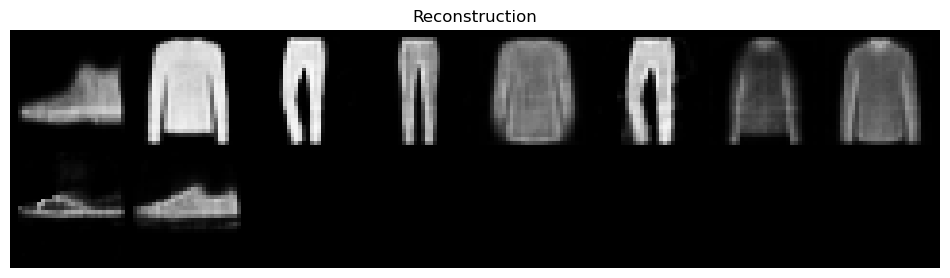

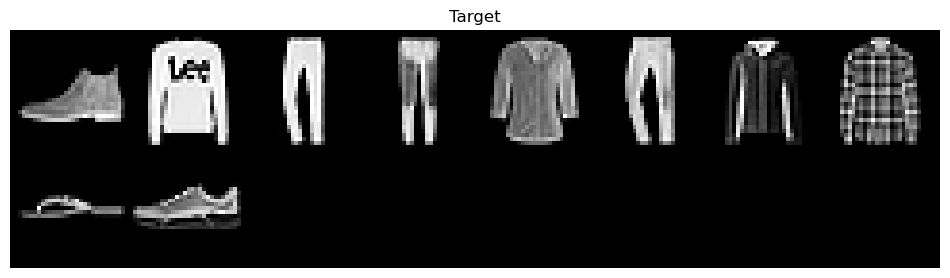


Test set: Average loss: 59.9906

The best (lowest) achieved loss: 59.991



In [11]:
# Task 1 training: fully connected autoencoder.
args.is_noisy = False
best_fc_loss = run_experiment(
    Autoencoder(),
    save_path='best_fc_autoencoder.pth',
    noisy=args.is_noisy,
)

# Task 2: Denoising Autoencoder

Use the same `Autoencoder` architecture from Task 1. This time, train the model with noisy inputs, but compute the reconstruction loss against the original clean image.

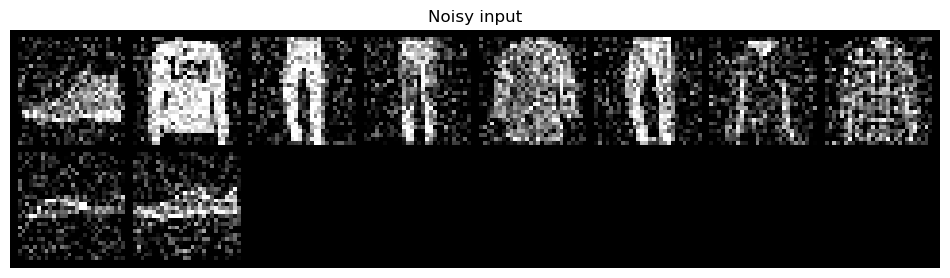

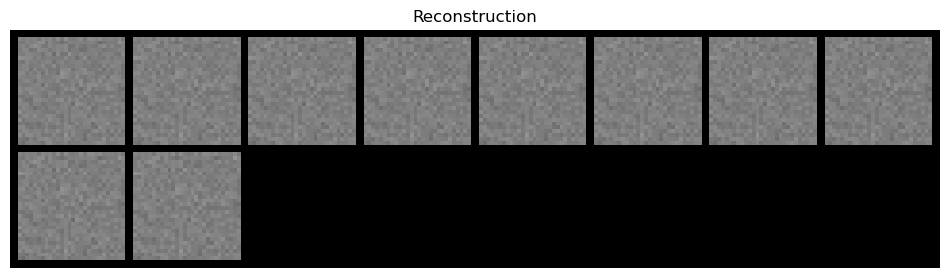

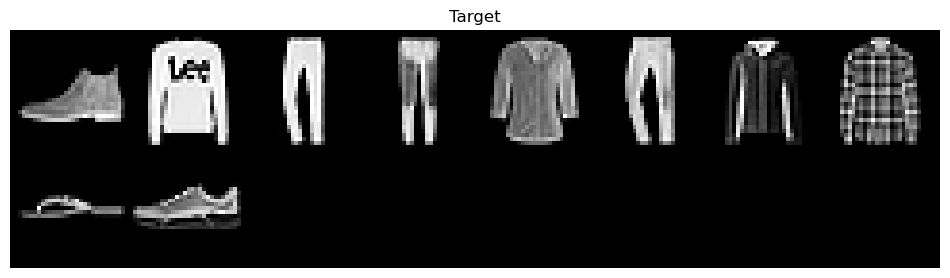


Test set: Average loss: 534.5256

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.676098
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.235327
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.166709
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.146526
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.142850
Train Epoch: 1 Average loss: 0.206297

Test set: Average loss: 113.9774

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.143529
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.129860
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.125377
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.118073
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.125623
Train Epoch: 2 Average loss: 0.129466

Test set: Average loss: 92.4380

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.111914
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.103188
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.121973
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.105286
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.110865
Train Epoch: 3 Average loss: 0.113227

Test set: Average loss: 85.2863

Train Epoch: 

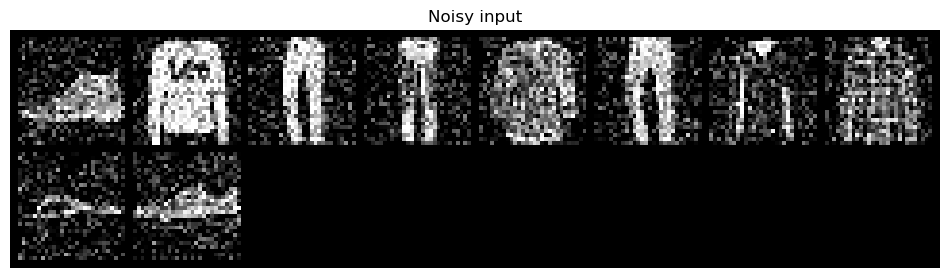

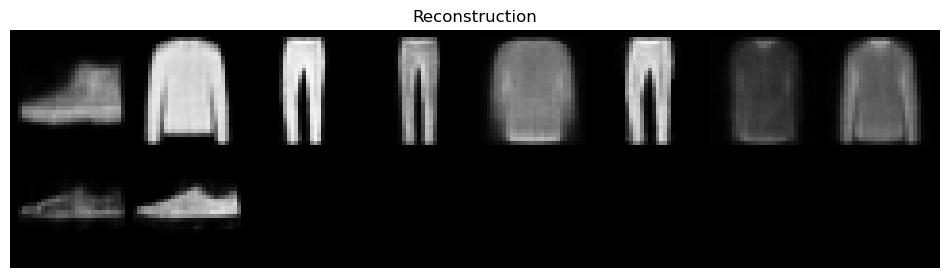

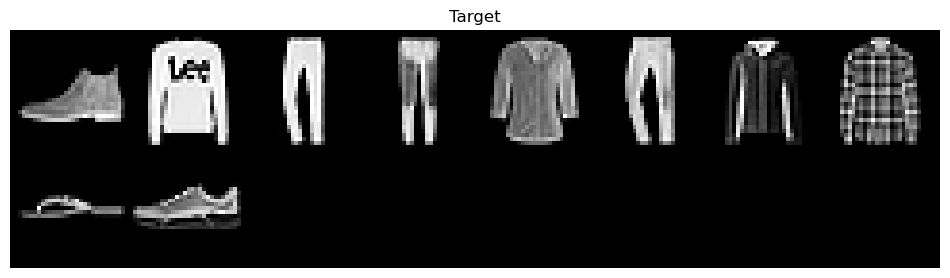


Test set: Average loss: 74.9033

Train Epoch: 11 [0/60000 (0%)]	Loss: 0.096699
Train Epoch: 11 [12800/60000 (21%)]	Loss: 0.096911
Train Epoch: 11 [25600/60000 (43%)]	Loss: 0.093033
Train Epoch: 11 [38400/60000 (64%)]	Loss: 0.099041
Train Epoch: 11 [51200/60000 (85%)]	Loss: 0.094803
Train Epoch: 11 Average loss: 0.094964

Test set: Average loss: 74.0908

Train Epoch: 12 [0/60000 (0%)]	Loss: 0.086641
Train Epoch: 12 [12800/60000 (21%)]	Loss: 0.090668
Train Epoch: 12 [25600/60000 (43%)]	Loss: 0.094483
Train Epoch: 12 [38400/60000 (64%)]	Loss: 0.094078
Train Epoch: 12 [51200/60000 (85%)]	Loss: 0.089689
Train Epoch: 12 Average loss: 0.094030

Test set: Average loss: 73.6318

Train Epoch: 13 [0/60000 (0%)]	Loss: 0.089847
Train Epoch: 13 [12800/60000 (21%)]	Loss: 0.098143
Train Epoch: 13 [25600/60000 (43%)]	Loss: 0.093338
Train Epoch: 13 [38400/60000 (64%)]	Loss: 0.091932
Train Epoch: 13 [51200/60000 (85%)]	Loss: 0.085244
Train Epoch: 13 Average loss: 0.093331

Test set: Average loss: 72.826

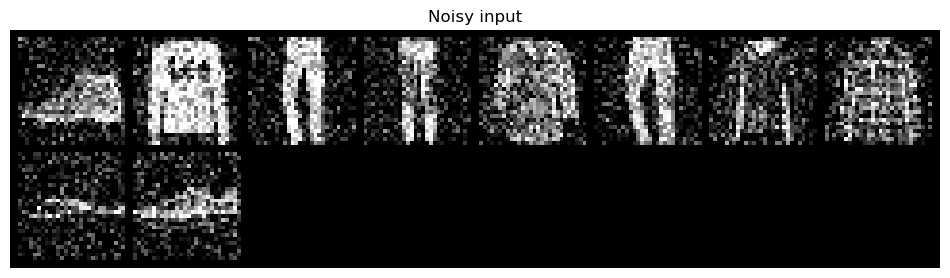

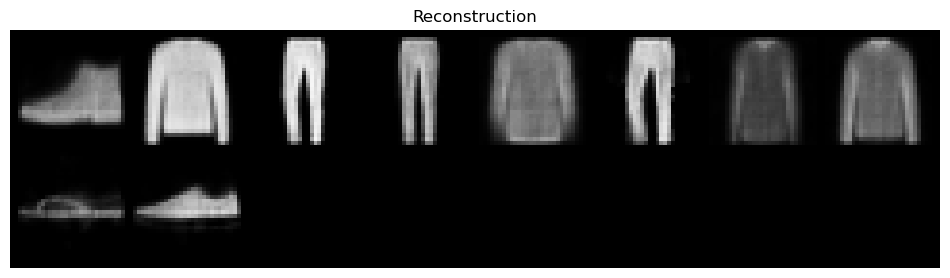

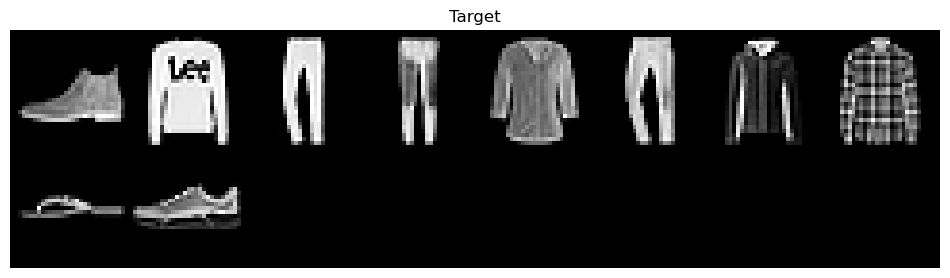


Test set: Average loss: 70.4675

Train Epoch: 21 [0/60000 (0%)]	Loss: 0.087446
Train Epoch: 21 [12800/60000 (21%)]	Loss: 0.089531
Train Epoch: 21 [25600/60000 (43%)]	Loss: 0.090167
Train Epoch: 21 [38400/60000 (64%)]	Loss: 0.090054
Train Epoch: 21 [51200/60000 (85%)]	Loss: 0.091028
Train Epoch: 21 Average loss: 0.088312

Test set: Average loss: 69.0263

Train Epoch: 22 [0/60000 (0%)]	Loss: 0.100156
Train Epoch: 22 [12800/60000 (21%)]	Loss: 0.077383
Train Epoch: 22 [25600/60000 (43%)]	Loss: 0.097044
Train Epoch: 22 [38400/60000 (64%)]	Loss: 0.080079
Train Epoch: 22 [51200/60000 (85%)]	Loss: 0.089800
Train Epoch: 22 Average loss: 0.085959

Test set: Average loss: 66.7340

Train Epoch: 23 [0/60000 (0%)]	Loss: 0.084346
Train Epoch: 23 [12800/60000 (21%)]	Loss: 0.084965
Train Epoch: 23 [25600/60000 (43%)]	Loss: 0.084169
Train Epoch: 23 [38400/60000 (64%)]	Loss: 0.082851
Train Epoch: 23 [51200/60000 (85%)]	Loss: 0.090202
Train Epoch: 23 Average loss: 0.084191

Test set: Average loss: 65.884

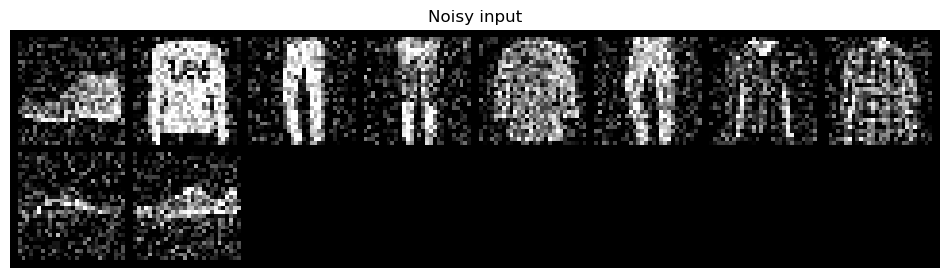

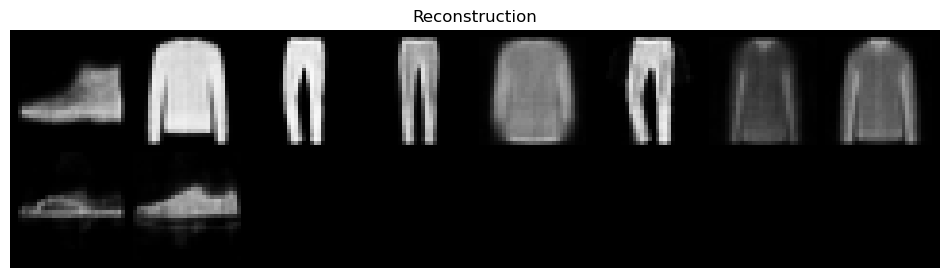

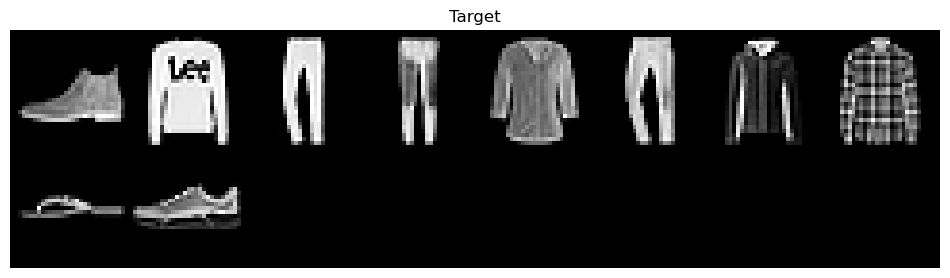


Test set: Average loss: 63.3737

Train Epoch: 31 [0/60000 (0%)]	Loss: 0.081379
Train Epoch: 31 [12800/60000 (21%)]	Loss: 0.083595
Train Epoch: 31 [25600/60000 (43%)]	Loss: 0.085769
Train Epoch: 31 [38400/60000 (64%)]	Loss: 0.084153
Train Epoch: 31 [51200/60000 (85%)]	Loss: 0.073114
Train Epoch: 31 Average loss: 0.080409

Test set: Average loss: 63.8410

Train Epoch: 32 [0/60000 (0%)]	Loss: 0.080911
Train Epoch: 32 [12800/60000 (21%)]	Loss: 0.082083
Train Epoch: 32 [25600/60000 (43%)]	Loss: 0.077991
Train Epoch: 32 [38400/60000 (64%)]	Loss: 0.074916
Train Epoch: 32 [51200/60000 (85%)]	Loss: 0.082196
Train Epoch: 32 Average loss: 0.080066

Test set: Average loss: 63.0774

Train Epoch: 33 [0/60000 (0%)]	Loss: 0.080524
Train Epoch: 33 [12800/60000 (21%)]	Loss: 0.086332
Train Epoch: 33 [25600/60000 (43%)]	Loss: 0.075134
Train Epoch: 33 [38400/60000 (64%)]	Loss: 0.087264
Train Epoch: 33 [51200/60000 (85%)]	Loss: 0.077809
Train Epoch: 33 Average loss: 0.079968

Test set: Average loss: 63.703

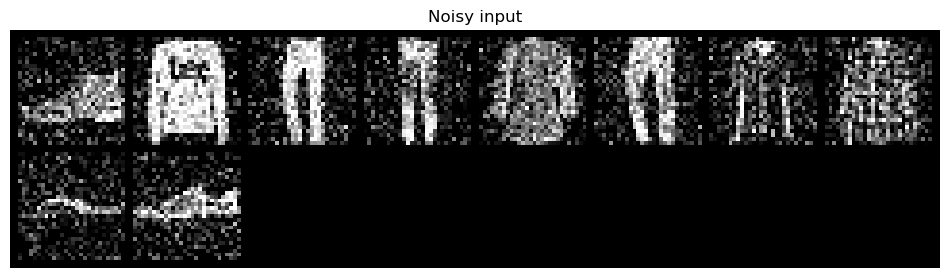

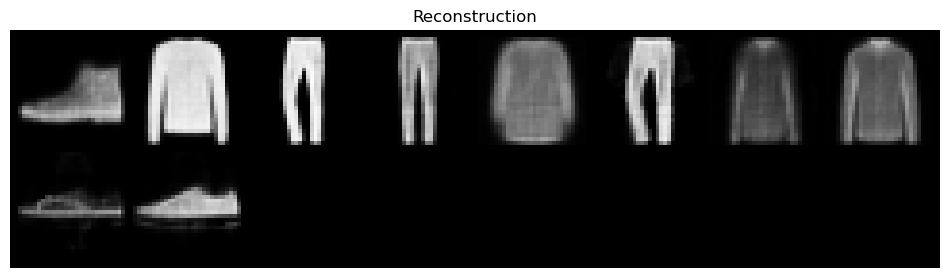

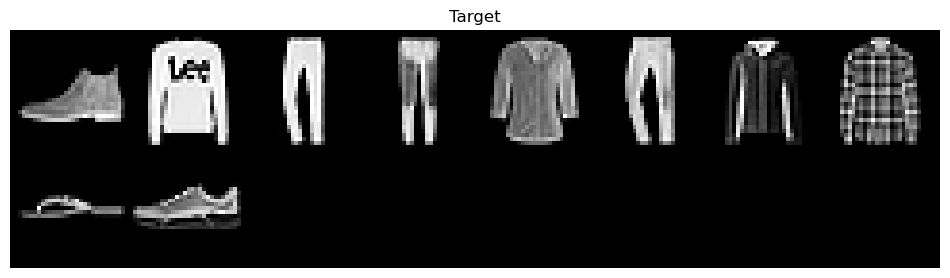


Test set: Average loss: 61.9904

Train Epoch: 41 [0/60000 (0%)]	Loss: 0.072168
Train Epoch: 41 [12800/60000 (21%)]	Loss: 0.080962
Train Epoch: 41 [25600/60000 (43%)]	Loss: 0.069428
Train Epoch: 41 [38400/60000 (64%)]	Loss: 0.074757
Train Epoch: 41 [51200/60000 (85%)]	Loss: 0.078903
Train Epoch: 41 Average loss: 0.078450

Test set: Average loss: 61.9229

Train Epoch: 42 [0/60000 (0%)]	Loss: 0.071410
Train Epoch: 42 [12800/60000 (21%)]	Loss: 0.080874
Train Epoch: 42 [25600/60000 (43%)]	Loss: 0.078306
Train Epoch: 42 [38400/60000 (64%)]	Loss: 0.091752
Train Epoch: 42 [51200/60000 (85%)]	Loss: 0.086349
Train Epoch: 42 Average loss: 0.078458

Test set: Average loss: 61.8874

Train Epoch: 43 [0/60000 (0%)]	Loss: 0.078657
Train Epoch: 43 [12800/60000 (21%)]	Loss: 0.077293
Train Epoch: 43 [25600/60000 (43%)]	Loss: 0.081325
Train Epoch: 43 [38400/60000 (64%)]	Loss: 0.074431
Train Epoch: 43 [51200/60000 (85%)]	Loss: 0.072393
Train Epoch: 43 Average loss: 0.078384

Test set: Average loss: 62.015

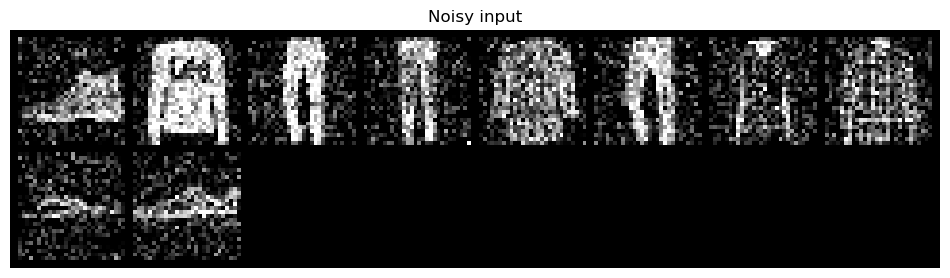

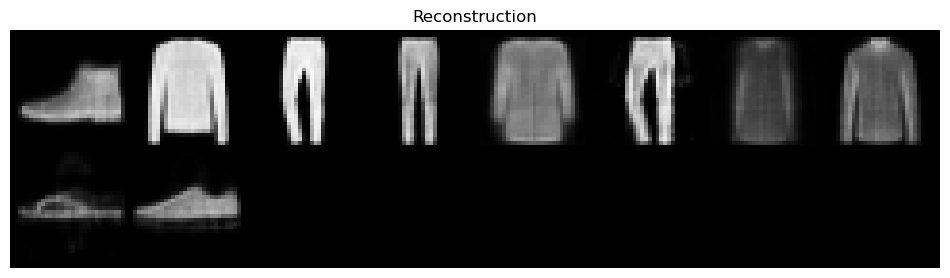

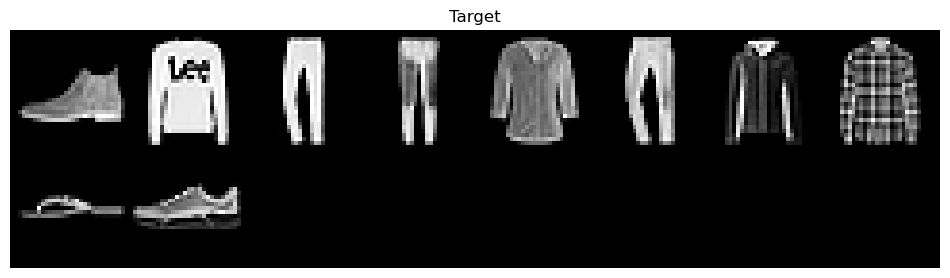


Test set: Average loss: 59.0620

The best (lowest) achieved loss: 59.062



In [12]:
# Task 2 training: denoising autoencoder.
args.is_noisy = True
best_fc_denoising_loss = run_experiment(
    Autoencoder(),
    save_path='best_fc_denoising_autoencoder.pth',
    noisy=args.is_noisy,
)

## Task 2 Written Answer

TODO 2.1: Briefly describe how the denoising autoencoder performs compared with the plain autoencoder. Mention the observed losses and the visual reconstruction quality.

Your answer:
The denoising outoencoder performs marginally better than the plain autoencoder (Average loss 59.0620 vs. 59.9906). However, while the visual reconstruction qualtiy is very similar for both versions of the autoencoder the denoising worked and the reconstruction removed the noise and resulting in a blured version of the original images.

# Task 3: Convolutional Autoencoder

Implement the `Conv_Autoencoder` class below.

Encoder architecture:

- `Conv2d(1, 4, kernel_size=5)` + `ReLU`
- `Conv2d(4, 8, kernel_size=5)` + `ReLU`
- `Flatten`
- `Linear(3200, 10)`
- `Softmax(dim=1)`

Decoder architecture:

- `Linear(10, 400)` + `ReLU`
- `Linear(400, 4000)` + `ReLU`
- `Unflatten` to `(10, 20, 20)`
- `ConvTranspose2d(10, 10, kernel_size=5)` + `ReLU`
- `ConvTranspose2d(10, 1, kernel_size=5)` + `Tanh`

In [23]:
class Conv_Autoencoder(nn.Module):
    def __init__(self):
        super(Conv_Autoencoder, self).__init__()

        encoder_layers = [
            nn.Conv2d(1, 4, kernel_size=5),
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size=5),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3200, 10),
            nn.Softmax(dim=1)
        ]
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = [
            nn.Linear(10, 400),
            nn.ReLU(),
            nn.Linear(400, 4000),
            nn.ReLU(),
            nn.Unflatten(1, (10, 20, 20)),
            nn.ConvTranspose2d(10, 10, kernel_size=5),
            nn.ReLU(),
            nn.ConvTranspose2d(10, 1, kernel_size=5),
            nn.Tanh(),  
        ]
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        latend_code = self.encoder(x)
        reconstruction = self.decoder(latend_code)
        return reconstruction.view(x.size(0), -1)

In [24]:
# Run this after completing Task 3. The output shape must match the flattened input shape.
conv_shape_test = Conv_Autoencoder()
with torch.no_grad():
    dummy = torch.randn(4, 28 * 28)
    assert conv_shape_test(dummy).shape == dummy.shape
print('Conv_Autoencoder shape check passed.')

Conv_Autoencoder shape check passed.


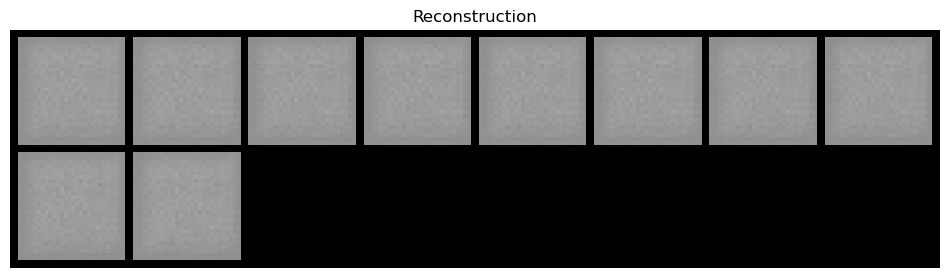

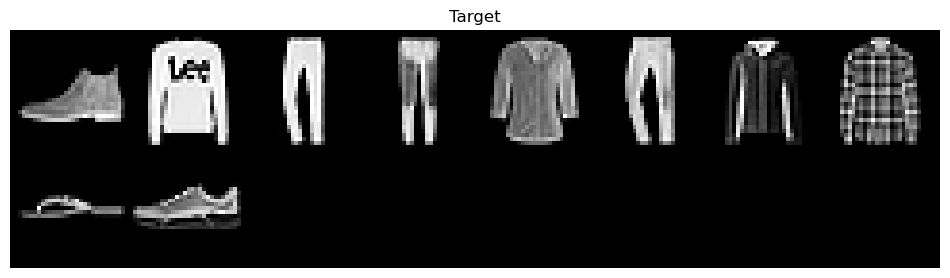


Test set: Average loss: 682.9933

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.864436
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.190494
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.114902
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.110240
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.097171
Train Epoch: 1 Average loss: 0.170379

Test set: Average loss: 72.5296

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.091211
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.088518
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.082501
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.080413
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.084636
Train Epoch: 2 Average loss: 0.086436

Test set: Average loss: 63.4587

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.083498
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.088613
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.081798
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.078628
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.074595
Train Epoch: 3 Average loss: 0.078625

Test set: Average loss: 59.5971

Train Epoch: 4

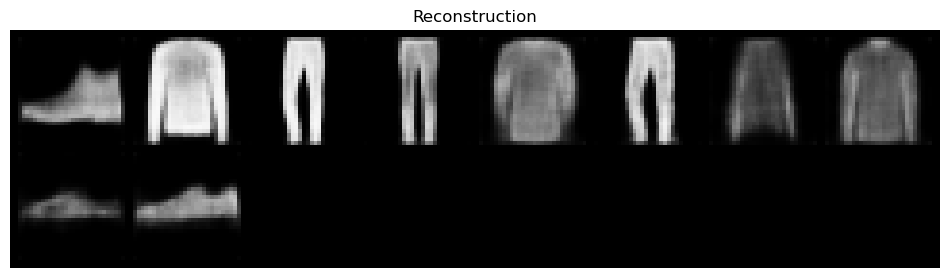

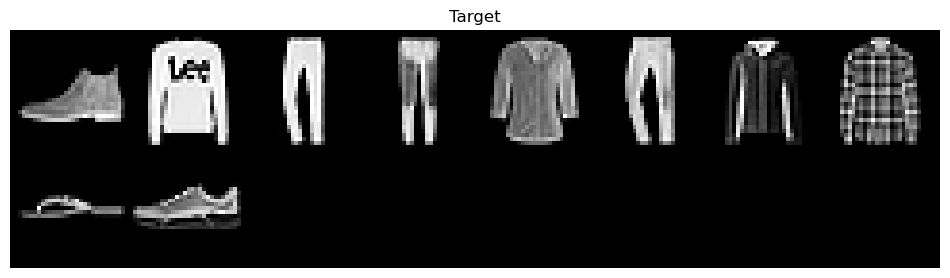


Test set: Average loss: 49.1460

Train Epoch: 11 [0/60000 (0%)]	Loss: 0.060998
Train Epoch: 11 [12800/60000 (21%)]	Loss: 0.065151
Train Epoch: 11 [25600/60000 (43%)]	Loss: 0.062631
Train Epoch: 11 [38400/60000 (64%)]	Loss: 0.055995
Train Epoch: 11 [51200/60000 (85%)]	Loss: 0.062957
Train Epoch: 11 Average loss: 0.062009

Test set: Average loss: 49.3139

Train Epoch: 12 [0/60000 (0%)]	Loss: 0.059408
Train Epoch: 12 [12800/60000 (21%)]	Loss: 0.051121
Train Epoch: 12 [25600/60000 (43%)]	Loss: 0.063347
Train Epoch: 12 [38400/60000 (64%)]	Loss: 0.067154
Train Epoch: 12 [51200/60000 (85%)]	Loss: 0.059706
Train Epoch: 12 Average loss: 0.061117

Test set: Average loss: 47.7320

Train Epoch: 13 [0/60000 (0%)]	Loss: 0.058009
Train Epoch: 13 [12800/60000 (21%)]	Loss: 0.060902
Train Epoch: 13 [25600/60000 (43%)]	Loss: 0.066688
Train Epoch: 13 [38400/60000 (64%)]	Loss: 0.057234
Train Epoch: 13 [51200/60000 (85%)]	Loss: 0.063114
Train Epoch: 13 Average loss: 0.060154

Test set: Average loss: 47.242

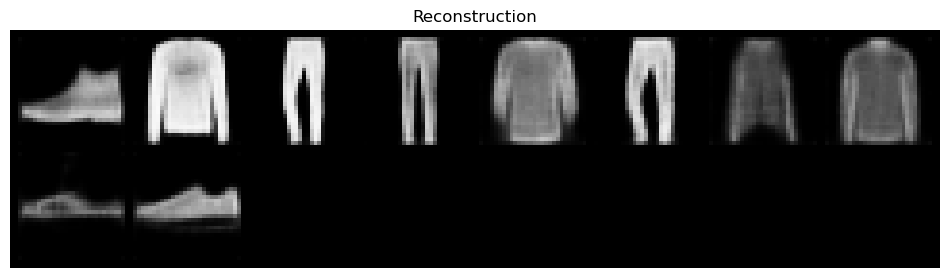

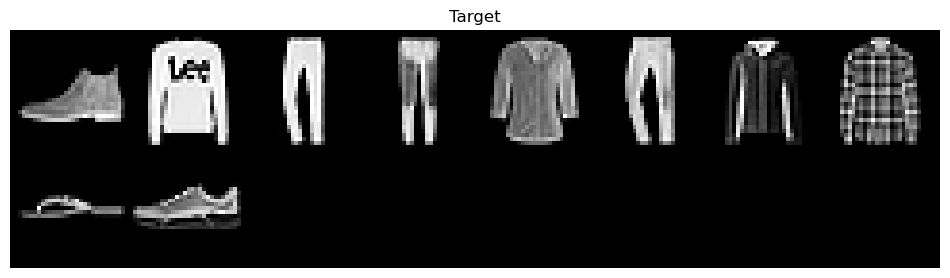


Test set: Average loss: 44.0524

Train Epoch: 21 [0/60000 (0%)]	Loss: 0.053268
Train Epoch: 21 [12800/60000 (21%)]	Loss: 0.058552
Train Epoch: 21 [25600/60000 (43%)]	Loss: 0.050551
Train Epoch: 21 [38400/60000 (64%)]	Loss: 0.046225
Train Epoch: 21 [51200/60000 (85%)]	Loss: 0.054658
Train Epoch: 21 Average loss: 0.055480

Test set: Average loss: 44.0462

Train Epoch: 22 [0/60000 (0%)]	Loss: 0.061282
Train Epoch: 22 [12800/60000 (21%)]	Loss: 0.053310
Train Epoch: 22 [25600/60000 (43%)]	Loss: 0.052182
Train Epoch: 22 [38400/60000 (64%)]	Loss: 0.052531
Train Epoch: 22 [51200/60000 (85%)]	Loss: 0.055873
Train Epoch: 22 Average loss: 0.055151

Test set: Average loss: 44.0184

Train Epoch: 23 [0/60000 (0%)]	Loss: 0.050865
Train Epoch: 23 [12800/60000 (21%)]	Loss: 0.051059
Train Epoch: 23 [25600/60000 (43%)]	Loss: 0.056417
Train Epoch: 23 [38400/60000 (64%)]	Loss: 0.055200
Train Epoch: 23 [51200/60000 (85%)]	Loss: 0.053582
Train Epoch: 23 Average loss: 0.054733

Test set: Average loss: 43.430

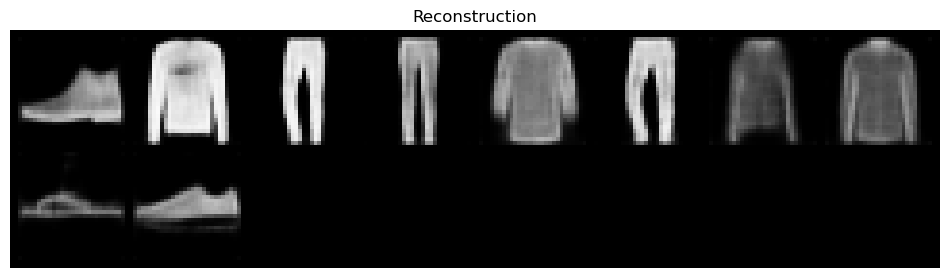

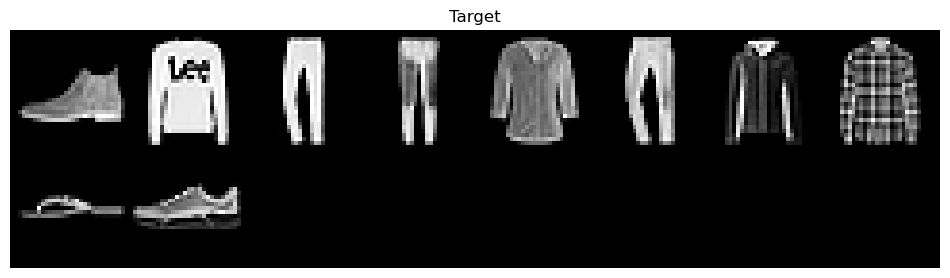


Test set: Average loss: 41.9400

Train Epoch: 31 [0/60000 (0%)]	Loss: 0.052655
Train Epoch: 31 [12800/60000 (21%)]	Loss: 0.055789
Train Epoch: 31 [25600/60000 (43%)]	Loss: 0.048808
Train Epoch: 31 [38400/60000 (64%)]	Loss: 0.054584
Train Epoch: 31 [51200/60000 (85%)]	Loss: 0.054113
Train Epoch: 31 Average loss: 0.052796

Test set: Average loss: 41.8682

Train Epoch: 32 [0/60000 (0%)]	Loss: 0.050558
Train Epoch: 32 [12800/60000 (21%)]	Loss: 0.056949
Train Epoch: 32 [25600/60000 (43%)]	Loss: 0.051939
Train Epoch: 32 [38400/60000 (64%)]	Loss: 0.055014
Train Epoch: 32 [51200/60000 (85%)]	Loss: 0.050709
Train Epoch: 32 Average loss: 0.052541

Test set: Average loss: 42.1858

Train Epoch: 33 [0/60000 (0%)]	Loss: 0.054073
Train Epoch: 33 [12800/60000 (21%)]	Loss: 0.049813
Train Epoch: 33 [25600/60000 (43%)]	Loss: 0.047973
Train Epoch: 33 [38400/60000 (64%)]	Loss: 0.048637
Train Epoch: 33 [51200/60000 (85%)]	Loss: 0.059194
Train Epoch: 33 Average loss: 0.052494

Test set: Average loss: 41.642

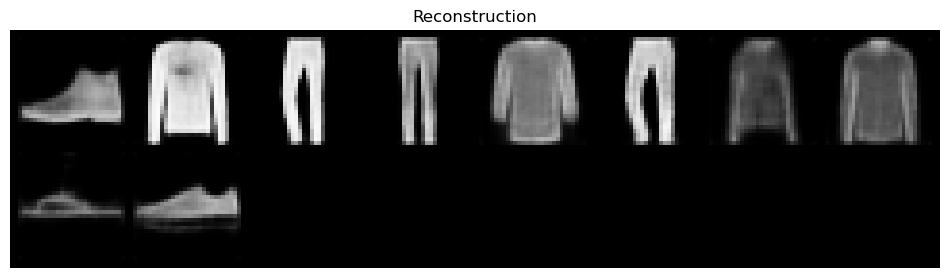

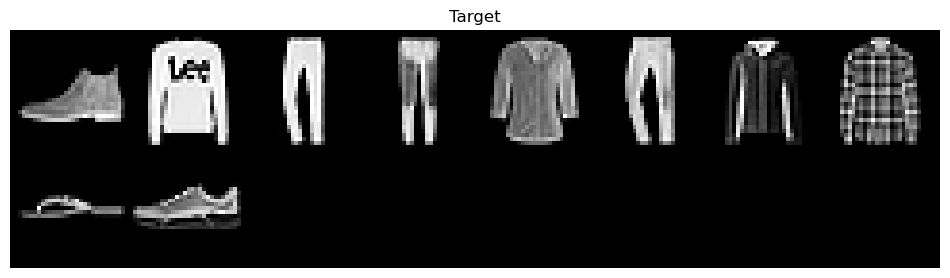


Test set: Average loss: 41.1154

Train Epoch: 41 [0/60000 (0%)]	Loss: 0.049031
Train Epoch: 41 [12800/60000 (21%)]	Loss: 0.049071
Train Epoch: 41 [25600/60000 (43%)]	Loss: 0.051498
Train Epoch: 41 [38400/60000 (64%)]	Loss: 0.047194
Train Epoch: 41 [51200/60000 (85%)]	Loss: 0.054586
Train Epoch: 41 Average loss: 0.051467

Test set: Average loss: 40.7409

Train Epoch: 42 [0/60000 (0%)]	Loss: 0.051907
Train Epoch: 42 [12800/60000 (21%)]	Loss: 0.052932
Train Epoch: 42 [25600/60000 (43%)]	Loss: 0.056008
Train Epoch: 42 [38400/60000 (64%)]	Loss: 0.053988
Train Epoch: 42 [51200/60000 (85%)]	Loss: 0.047935
Train Epoch: 42 Average loss: 0.051382

Test set: Average loss: 40.9201

Train Epoch: 43 [0/60000 (0%)]	Loss: 0.052719
Train Epoch: 43 [12800/60000 (21%)]	Loss: 0.054053
Train Epoch: 43 [25600/60000 (43%)]	Loss: 0.049777
Train Epoch: 43 [38400/60000 (64%)]	Loss: 0.063259
Train Epoch: 43 [51200/60000 (85%)]	Loss: 0.049051
Train Epoch: 43 Average loss: 0.051239

Test set: Average loss: 41.049

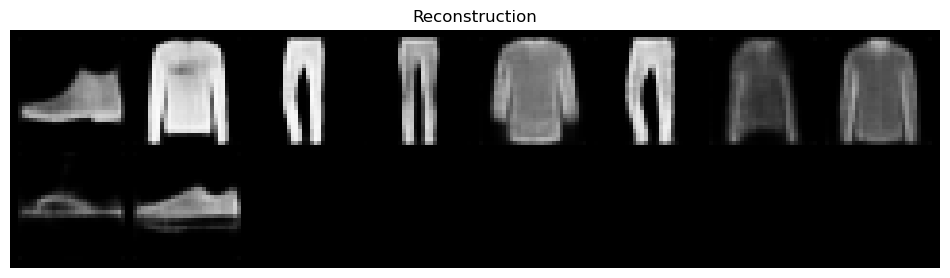

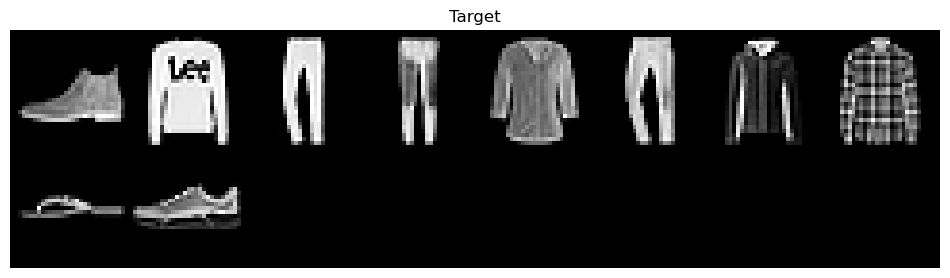


Test set: Average loss: 40.6148

The best (lowest) achieved loss: 40.615



In [25]:
# Task 3 training: convolutional autoencoder.
args.is_noisy = False
best_conv_loss = run_experiment(
    Conv_Autoencoder(),
    save_path='best_conv_autoencoder.pth',
    noisy=args.is_noisy,
)

## Task 3 Written Answer

TODO 3.4: Compare the convolutional autoencoder to the fully connected autoencoder in 2-3 sentences. Mention both loss and visual reconstruction quality. 

Your answer:
The convolutional autoencoder has a signigicantly lower average loss of 40.6148 than the fully connected autoencoder with a average loss of 59.9906. Furthermore the conv autoencoder shows small visual improvements like the beginings of the logo on the white shirt in the upper left corner.  
